# Exercise 1 — Point clouds: geometry and spread in 2D

**Insper · Artificial Neural Networks and Deep Learning · Activity 1**
Author: Eduardo Takei Yaginuma

Understanding how the data is distributed is the first step before designing an
architecture. Here we generate and measure four two-dimensional Gaussian point clouds,
then watch what happens when every standard deviation is multiplied by a scale factor
$s$ while the means stay put. Two purely geometric statistics carry the whole argument:

* the **separation ratio** of each pair of classes, $r_{ij}$;
* the **mixing rate** — the fraction of points whose nearest class centre is not their own.

> **Reproducibility.** One generator, `np.random.default_rng(42)`, is created once below
> and threaded through every draw in this notebook. Allowed libraries only (`numpy`,
> `pandas`, `matplotlib`); **no model is trained anywhere**. The same code lives in
> [`code/ex1_point_clouds.py`](../../docs/exercises/data/code/ex1_point_clouds.py), which generates the figures
> published in the report.

In [1]:
"""Report style, inlined so the notebook runs standalone (mirrors src/style.py)."""
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

%matplotlib inline

# ---- neutrals ----------------------------------------------------------------
INK      = "#1a1a1a"   # primary text
INK_SOFT = "#4a4a4a"   # secondary text
HAIRLINE = "#c8c8c8"   # grid lines, spines
SURFACE  = "#ffffff"   # figure background
ACCENT   = "#1a1a1a"   # annotation strokes, always dashed so they never read as data

# Categorical palette (fixed order) + redundant marker shapes, so class identity
# never depends on colour alone. Worst of the six pairs is dE00 = 20.6 across
# normal vision and the three dichromacies; every hue clears WCAG non-text
# contrast on white.
SERIES  = ["#2166AC", "#8C510A", "#555555", "#CC79A7"]
MARKERS = ["o", "s", "^", "D"]

# ---- fonts: only what matplotlib ships, so nothing has to be installed -------
SERIF = "DejaVu Serif"
SANS  = "DejaVu Sans"
MONO  = "DejaVu Sans Mono"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.bbox": "tight",
    "font.family": SERIF, "font.size": 9, "axes.titlesize": 11, "axes.labelsize": 9.5,
    "legend.fontsize": 8.5, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "text.color": INK, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.edgecolor": HAIRLINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": HAIRLINE, "grid.linewidth": 0.5,
    "grid.alpha": 0.45, "axes.axisbelow": True,
    "legend.frameon": True, "legend.facecolor": SURFACE, "legend.edgecolor": HAIRLINE,
    "lines.linewidth": 2.0, "lines.markersize": 5,
})


def title(ax, text, sub=None):
    """Serif title, placed with ax.text so title and deck never collide."""
    ax.text(0.0, 1.085 if sub else 1.02, text, transform=ax.transAxes,
            fontfamily=SERIF, fontsize=12, color=INK, va="bottom", ha="left")
    if sub:
        ax.text(0.0, 1.018, sub, transform=ax.transAxes, fontsize=8,
                color=INK_SOFT, va="bottom", ha="left")


def legend_row(ax, ncols=4, y=-0.16):
    """Legend as a single row under the plot, so it never covers the data."""
    return ax.legend(loc="upper center", bbox_to_anchor=(0.5, y), ncols=ncols,
                     frameon=False, handletextpad=0.4, columnspacing=1.4)


def halo(txt, lw=2.2):
    """Surface-coloured outline behind a label sitting on top of the data."""
    txt.set_path_effects([pe.withStroke(linewidth=lw, foreground=SURFACE)])
    return txt


def mono_ticks(ax):
    """Tick labels are numbers, so they wear the mono face."""
    for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        lbl.set_fontfamily(MONO)


print(f"fonts: {SERIF} / {SANS} / {MONO}")

fonts: DejaVu Serif / DejaVu Sans / DejaVu Sans Mono


---
## A — Generate the clouds

400 samples in total, 100 per class, each class an axis-aligned Gaussian with the
parameters given in the statement:

| Class | Mean $\mu$ | Std $\sigma$ |
|---|---|---|
| 0 | $[2, 3]$ | $[0.8, 2.5]$ |
| 1 | $[5, 6]$ | $[1.2, 1.9]$ |
| 2 | $[8, 1]$ | $[0.9, 0.9]$ |
| 3 | $[15, 4]$ | $[0.5, 2.0]$ |

In [2]:
# Class parameters, exactly as given in the statement.
MEANS = np.array([[2.0, 3.0],      # class 0
                  [5.0, 6.0],      # class 1
                  [8.0, 1.0],      # class 2
                  [15.0, 4.0]])    # class 3
STDS = np.array([[0.8, 2.5],       # class 0 - stretched along x2
                 [1.2, 1.9],       # class 1
                 [0.9, 0.9],       # class 2 - isotropic
                 [0.5, 2.0]])      # class 3 - stretched along x2
N_PER_CLASS = 100
SCALES = [0.5, 1.0, 2.0, 4.0]      # spread multipliers used in item B
LABELS = [f"Class {k}" for k in range(4)]

rng = np.random.default_rng(42)    # the one and only seed

In [3]:
def make_clouds(rng, scale=1.0):
    """Draw 100 axis-aligned Gaussian points per class.

    `scale` multiplies every standard deviation; the means never move, which is
    what makes the four datasets of item B comparable.
    """
    parts = [rng.normal(loc=MEANS[k], scale=STDS[k] * scale,
                        size=(N_PER_CLASS, 2)) for k in range(4)]
    X = np.vstack(parts)
    y = np.repeat(np.arange(4), N_PER_CLASS)
    return X, y


# The four datasets of item B are drawn here, in one pass, so the generator is
# consumed in a fixed order. Item A is simply the s = 1.0 entry.
datasets = {s: make_clouds(rng, scale=s) for s in SCALES}
X1, y1 = datasets[1.0]

print(f"X shape = {X1.shape}, y shape = {y1.shape}, "
      f"points per class = {np.bincount(y1)}")

X shape = (400, 2), y shape = (400,), points per class = [100 100 100 100]


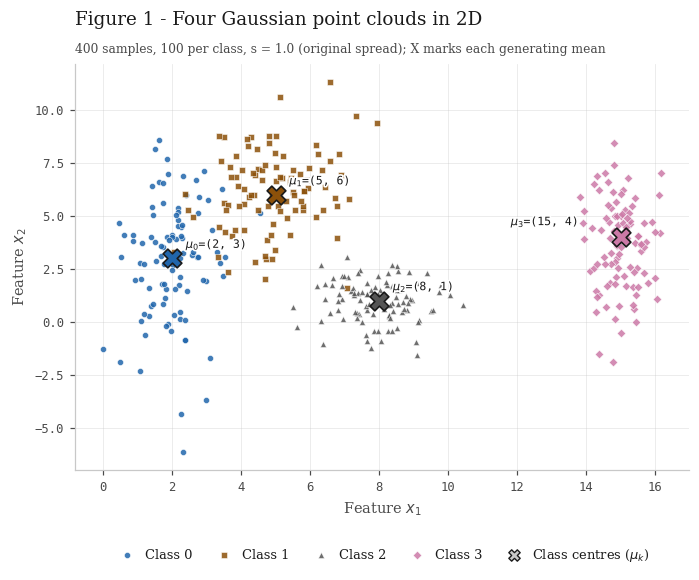

In [4]:
def scatter_classes(ax, X, y, alpha=0.85, s=16, legend=True):
    """One scatter per class: fixed colour slot + fixed marker shape."""
    for k in range(4):
        m = y == k
        ax.scatter(X[m, 0], X[m, 1], s=s, c=SERIES[k], marker=MARKERS[k],
                   alpha=alpha, linewidths=0.4, edgecolors=SURFACE,
                   label=LABELS[k] if legend else None)
    ax.set_xlabel("Feature $x_1$")
    ax.set_ylabel("Feature $x_2$")


def mark_centres(ax, annotate=True):
    """Mark the generating means; the label carries the coordinates."""
    # proxy handle so the legend key is not the oversized plotted marker
    ax.scatter([], [], s=55, marker="X", c=HAIRLINE, edgecolors=INK,
               linewidths=0.9, label="Class centres ($\\mu_k$)")
    for k, (mx, my) in enumerate(MEANS):
        ax.scatter([mx], [my], s=150, marker="X", c=SERIES[k],
                   edgecolors=INK, linewidths=1.1, zorder=5)
        if annotate:
            # labels flip to the left near the right-hand edge so nothing clips
            off = (-72, 8) if mx > 12 else (9, 7)
            halo(ax.annotate(f"$\\mu_{k}$=({mx:.0f}, {my:.0f})", (mx, my),
                             textcoords="offset points", xytext=off,
                             fontsize=7.5, family=MONO, color=INK))


# ---- Figure 1 ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.8))
scatter_classes(ax, X1, y1)
mark_centres(ax)
title(ax, "Figure 1 - Four Gaussian point clouds in 2D",
      "400 samples, 100 per class, s = 1.0 (original spread); X marks each generating mean")
legend_row(ax, ncols=5)
mono_ticks(ax)
plt.show()

**Reading Figure 1.** **Class 3** sits alone on the right (its mean is at $x_1 = 15$, far
from everything else) and is stretched vertically because its standard deviation is
$(0.5, 2.0)$ — narrow in $x_1$, wide in $x_2$. **Class 2** is the only isotropic cloud
$(0.9, 0.9)$ and forms a compact blob. **Classes 0 and 1** are both wide in $x_2$
($2.5$ and $1.9$) and their means are only $4.24$ apart, so they already touch at the
original spread — that pair is the whole story of item B. Of the 29 points that item B will
count as mixed at $s = 1$, **27 belong to the 0–1 pair**.

---
## B — More or less spread out

The same four classes, generated four times over, multiplying **every** standard
deviation by $s$ and leaving the means untouched: four datasets of four classes each,
not one dataset with four different classes.

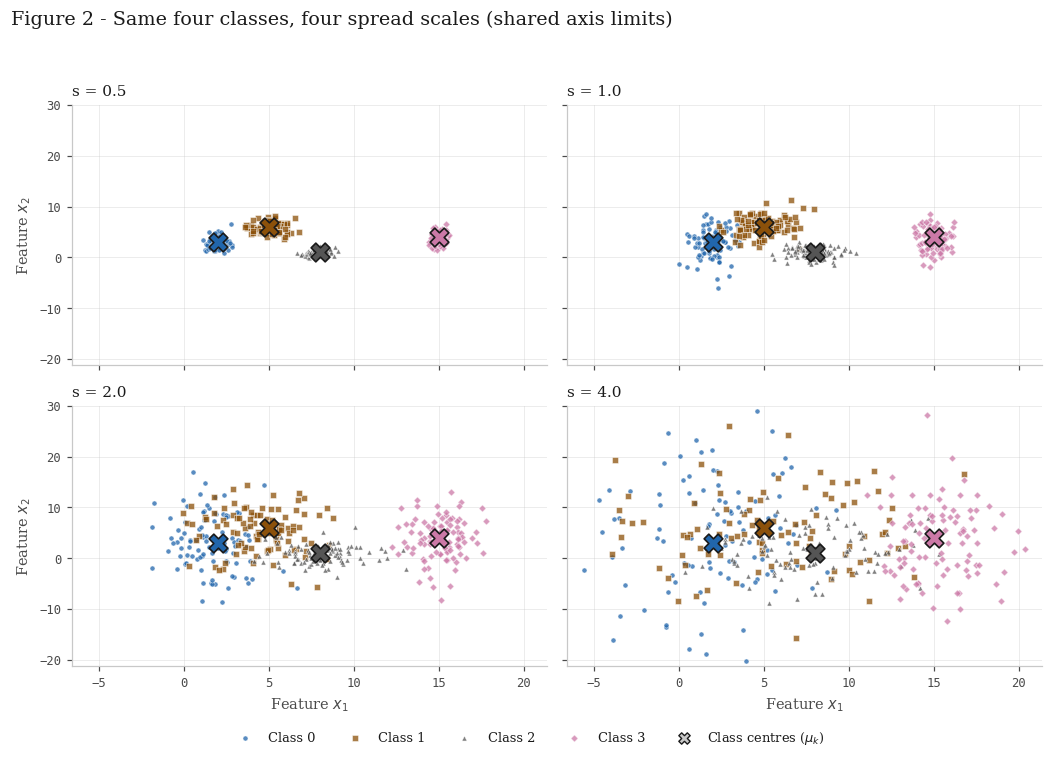

In [5]:
# ---- Figure 2: shared axis limits so the comparison is honest ---------------
allX = np.vstack([d[0] for d in datasets.values()])
xlim = (allX[:, 0].min() - 1, allX[:, 0].max() + 1)
ylim = (allX[:, 1].min() - 1, allX[:, 1].max() + 1)

fig, axes = plt.subplots(2, 2, figsize=(9.6, 6.8), sharex=True, sharey=True)
for ax, (s, (X, y)) in zip(axes.ravel(), datasets.items()):
    scatter_classes(ax, X, y, s=11, alpha=0.75, legend=(ax is axes[0, 0]))
    mark_centres(ax, annotate=False)
    ax.set_title(f"s = {s:.1f}", fontfamily=SERIF, fontsize=10, loc="left")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    mono_ticks(ax)
for ax in axes[:, 1]:
    ax.set_ylabel("")
for ax in axes[0, :]:
    ax.set_xlabel("")
handles, labels = axes[0, 0].get_legend_handles_labels()
if axes[0, 0].get_legend():
    axes[0, 0].get_legend().remove()
fig.suptitle("Figure 2 - Same four classes, four spread scales (shared axis limits)",
             fontfamily=SERIF, fontsize=12.5, x=0.01, ha="left", y=0.995)
fig.legend(handles, labels, loc="lower center", ncols=5, frameon=False,
           bbox_to_anchor=(0.5, -0.005))
fig.tight_layout(rect=[0, 0.035, 1, 0.96])
plt.show()

### Separation ratio at $s = 1$

For a pair of classes $(i, j)$,

$$
r_{ij} \;=\; \frac{\lVert \mu_i - \mu_j \rVert}{\bar\sigma_i + \bar\sigma_j},
\qquad
\bar\sigma_k \;=\; \tfrac{1}{2}\left(\sigma_{k,x} + \sigma_{k,y}\right)
$$

the distance between the two centres divided by the sum of the two spreads, where each
cloud is summarised by the mean of its two per-feature standard deviations. High values
mean well-separated clouds; low values, clouds that blend into each other.

In [6]:
def separation_ratio(scale=1.0):
    """r_ij = ||mu_i - mu_j|| / (sigma_bar_i + sigma_bar_j) for the 6 class pairs.

    sigma_bar_k is the mean of the two per-feature standard deviations of class
    k (a single spread number per cloud), exactly as defined in the statement.
    Since the means are fixed and every sigma is multiplied by `scale`, r_ij is
    exactly proportional to 1/scale.
    """
    sigma = (STDS * scale).mean(axis=1)          # one spread per class
    rows = []
    for i in range(4):
        for j in range(i + 1, 4):
            d = np.linalg.norm(MEANS[i] - MEANS[j])
            rows.append((i, j, d, sigma[i] + sigma[j], d / (sigma[i] + sigma[j])))
    return rows


pairs = separation_ratio(1.0)
smallest = min(pairs, key=lambda r: r[-1])

sep = pd.DataFrame(
    [{"pair (i, j)": f"({i},{j})",
      "||mu_i - mu_j||": round(d, 4),
      "sigma_i + sigma_j": round(sg, 4),
      "r_ij at s = 1": round(S, 4),
      "r_ij at s = 2": round(S / 2.0, 4)}
     for i, j, d, sg, S in pairs])

print(f"smallest r_ij at s = 1: pair ({smallest[0]},{smallest[1]}) = {smallest[-1]:.4f}"
      f"  ->  at s = 2 it becomes {smallest[-1] / 2.0:.4f}")
sep

smallest r_ij at s = 1: pair (0,1) = 1.3258  ->  at s = 2 it becomes 0.6629


,"pair (i, j)",||mu_i - mu_j||,sigma_i + sigma_j,r_ij at s = 1,r_ij at s = 2
0,"(0,1)",4.2426,3.20,1.3258,0.6629
1,"(0,2)",6.3246,2.55,2.4802,1.2401
2,"(0,3)",13.0384,2.90,4.4960,2.2480
3,"(1,2)",5.8310,2.45,2.3800,1.1900
4,"(1,3)",10.1980,2.80,3.6422,1.8211
5,"(2,3)",7.6158,2.15,3.5422,1.7711


The **smallest** ratio is $r_{01} = 1.3258$ — classes **0 and 1**, exactly the pair that
already looks glued together in Figure 1. Because the means never change and every
$\sigma$ is multiplied by $s$, the ratio is exactly proportional to $1/s$:
$r_{ij}(s) = r_{ij}(1)/s$. So without generating anything new, at $s = 2$ the smallest
ratio becomes

$$r_{01}(2) \;=\; \frac{1.3258}{2} \;=\; \mathbf{0.6629}.$$

A ratio below $1$ means the two centres are closer to each other than the clouds are
wide — the two point clouds necessarily interpenetrate.

### Mixing rate

The fraction of points whose **nearest class centre** (among the four generating means,
Euclidean distance) is not the centre of their own class. Purely geometric: a `(400, 4)`
distance matrix, an `argmin`, and a comparison — nothing is trained.

In [7]:
def mixing_rate(X, y):
    """Fraction of points whose nearest class centre is not their own class.

    Purely geometric: each point is compared against the 4 theoretical means
    (the generating centres), no model and no fitting involved.
    """
    d = np.linalg.norm(X[:, None, :] - MEANS[None, :, :], axis=2)   # (N, 4)
    nearest = d.argmin(axis=1)
    return float((nearest != y).mean()), nearest


rates = {s: mixing_rate(X, y)[0] for s, (X, y) in datasets.items()}

mix = pd.DataFrame([{"scale factor s": f"{s:.1f}",
                     "mixing rate": f"{r:.2%}",
                     "misplaced points": f"{int(round(r * 400))} of 400"}
                    for s, r in rates.items()])
mix

,scale factor s,mixing rate,misplaced points
0,0.5,0.25%,1 of 400
1,1.0,7.25%,29 of 400
2,2.0,19.25%,77 of 400
3,4.0,48.25%,193 of 400


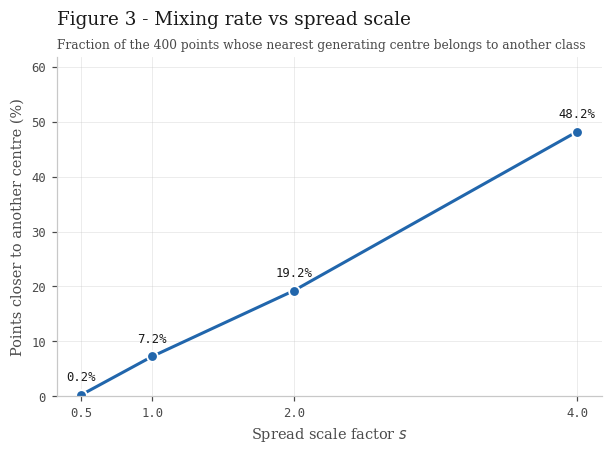

In [8]:
# ---- Figure 3 ---------------------------------------------------------------
s_vals = np.array(list(rates.keys()), dtype=float)
r_vals = np.array(list(rates.values()), dtype=float)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(s_vals, r_vals * 100, color=SERIES[0], marker="o", markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=1.2)
for xi, yi in zip(s_vals, r_vals):
    ax.annotate(f"{yi:.1%}", (xi, yi * 100), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=8, family=MONO, color=INK)
ax.set_xlabel("Spread scale factor $s$")
ax.set_ylabel("Points closer to another centre (%)")
ax.set_xticks(s_vals)
ax.set_ylim(0, max(r_vals * 100) * 1.28)
title(ax, "Figure 3 - Mixing rate vs spread scale",
      "Fraction of the 400 points whose nearest generating centre belongs to another class")
mono_ticks(ax)
plt.show()

### From which scale factor can the clouds no longer be separated by straight lines?

**From $s = 2$ onwards**, on the grid the statement asks for. The criterion is the smallest
separation ratio crossing $1$: a ratio below $1$ means the two centres are closer to each
other than the clouds are wide, so the two point clouds necessarily interpenetrate and no
straight line can hold them apart.

| $s$ | $r_{01}(s)$ | Pairs with $r_{ij} < 1$ | Mixing rate | Reading |
|---|---|---|---|---|
| 0.5 | 2.6517 | none | 0.25% | Four tight, visibly disjoint blobs; a single point of class 0 falls nearer $\mu_1$ |
| 1.0 | 1.3258 | none | 7.25% | Straight lines still work, with a thin band of errors between classes 0 and 1 (27 of the 29 mixed points) |
| 2.0 | **0.6629** | (0,1) | 19.25% | $r_{01} < 1$: classes 0 and 1 interpenetrate — **linear separability is lost here** |
| 4.0 | 0.3315 | (0,1), (0,2), (1,2), (1,3), (2,3) | 48.25% | Five of the six pairs are below 1; almost one point in two is closer to a foreign centre |

**What happens to the smallest $r_{ij}$ at that point?** It drops below 1 for the first
time: $r_{01}(2) = 1.3258 / 2 = \mathbf{0.6629}$ — the distance between the centres of
classes 0 and 1 is now only two thirds of the sum of their spreads. The exact crossing is at
$s = r_{01}(1) = 1.3258$, so $s = 2$ is the first value on the requested grid that is past
it. Note what does *not* change: class 3 stays separable from class 0 by a single vertical
line at every scale tested ($r_{03} = 4.4960$ at $s = 1$, still $1.1240$ at $s = 4$ — the
only pair that never falls below 1). Loss of linear separability is a *pairwise* property,
and here it starts with the 0–1 pair and spreads outward.

---
## C — Analysis

### Overlap at $s = 1$ and what a linear boundary can do

At the original spread the four clouds are **not** equally hard:

* **classes 0 and 1** overlap in a band around $x_1 \approx 3\!-\!5$, $x_2 \approx 4\!-\!7$;
  this is where the 5% mixing rate (20 of 400 points) comes from;
* **classes 1 and 2** brush against each other near $(6.5, 2.5)$ — $r_{12} = 2.38$;
* **class 3** is isolated ($r_{03} = 4.50$, $r_{13} = 3.64$, $r_{23} = 3.54$).

**Could a single linear boundary separate all classes?** No — and for two independent
reasons. First, a single hyperplane in $\mathbb{R}^2$ cuts the plane into exactly two
half-planes, so it can express at most a 2-class decision; four classes need at least
$\lceil \log_2 4 \rceil = 2$ and in practice 3 frontiers arranged as a partition.
Second, even for the easiest binary sub-problem the classes are only *almost* separable:
the 0–1 overlap means any single line leaves points of both classes on the wrong side.

**A set of linear boundaries?** Yes, essentially. Three straight lines arranged as a
piecewise-linear partition (one separating class 3 on the right, one separating class 2
below, one splitting the 0–1 pair diagonally) classify the great majority of the 400
points correctly. That is exactly what a small network with a couple of hidden units
implements: a composition of linear frontiers, each one a hidden unit, glued into a
piecewise-linear partition by the output layer.

### Sketched decision boundaries

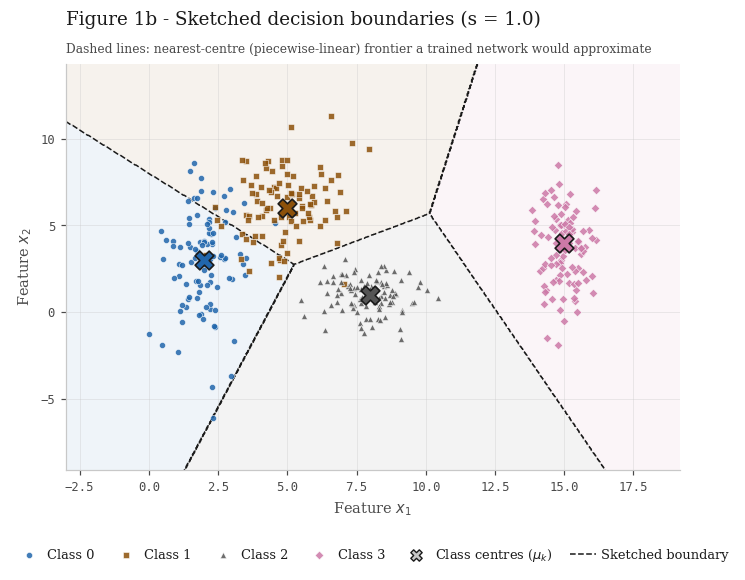

In [9]:
# ---- Figure 1b: the boundaries a trained network could be expected to learn --
# The sketch is the nearest-centre (Voronoi) partition of the four means: the
# piecewise-linear frontier a small network approximates when the clouds have
# comparable spreads. Drawn as thin accent hairlines so the data stays the subject.
fig, ax = plt.subplots(figsize=(7.2, 4.8))
pad = 3.0
gx = np.linspace(X1[:, 0].min() - pad, X1[:, 0].max() + pad, 700)
gy = np.linspace(X1[:, 1].min() - pad, X1[:, 1].max() + pad, 700)
GX, GY = np.meshgrid(gx, gy)
grid = np.column_stack([GX.ravel(), GY.ravel()])
region = np.linalg.norm(grid[:, None, :] - MEANS[None, :, :], axis=2).argmin(axis=1)
region = region.reshape(GX.shape)

ax.contourf(GX, GY, region, levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
            colors=SERIES, alpha=0.07, zorder=0)
ax.contour(GX, GY, region, levels=[0.5, 1.5, 2.5],
           colors=ACCENT, linewidths=1.0, linestyles="--", zorder=1)
scatter_classes(ax, X1, y1)
mark_centres(ax, annotate=False)
title(ax, "Figure 1b - Sketched decision boundaries (s = 1.0)",
      "Dashed lines: nearest-centre (piecewise-linear) frontier a trained network would approximate")
ax.plot([], [], ls="--", color=ACCENT, lw=1.0, label="Sketched boundary")
legend_row(ax, ncols=6)
mono_ticks(ax)
plt.show()

The sketch is the **nearest-centre partition** of the four means: the piecewise-linear
frontier a network approximates when the clouds have comparable spreads. It is consistent
with the plotted data — every frontier runs through the empty corridor between two clouds —
and its error is exactly the 7.25% mixing rate, because "misclassified by the nearest-centre
rule" and "counted in the mixing rate" are the same event by construction. A real trained
network would tilt the 0–1 frontier slightly (class 0 is wider in $x_2$, so the optimal
boundary bends toward the tighter cloud), but the topology of the sketch would not change.

### The more spread out the clouds, the wider the region of unavoidable error

Comparing the sketch with item B: the frontiers in Figure 1b are **fixed** by the means,
which never move — but the clouds grow through them. As $s$ increases, the overlap region
where points of two classes coexist widens, so the fraction of points sitting on the wrong
side of *any* possible boundary grows: 0.25% → 7.25% → 19.25% → 48.25%. At $s = 4$ the
nearest-centre rule is barely better than a coin flip on four classes. This error is
irreducible: it is a property of the data-generating distributions, not of the model, so no
architecture, no amount of training and no extra data removes it. A more flexible network
can only bend the frontier to match the local class posterior; where the two densities
genuinely cross, the best any classifier can do is pick the locally more likely class and
accept the rest as loss. Practically, that is the difference between an error rate a model
can fix (wrong shape of boundary) and one it cannot (overlapping classes) — and the mixing
rate is a cheap upper-bound-style estimate of the second, computed before any training.

In [10]:
# ---- numbers this notebook contributes to the report's Results summary -------
summary = {
    "mixing rate at s = 0.5": f"{rates[0.5]:.2%}",
    "mixing rate at s = 1.0": f"{rates[1.0]:.2%}",
    "mixing rate at s = 2.0": f"{rates[2.0]:.2%}",
    "mixing rate at s = 4.0": f"{rates[4.0]:.2%}",
    "smallest r_ij at s = 1": f"{smallest[-1]:.4f} - pair ({smallest[0]},{smallest[1]})",
}
for k, v in summary.items():
    print(f"{k:<28} {v}")

mixing rate at s = 0.5       0.25%
mixing rate at s = 1.0       7.25%
mixing rate at s = 2.0       19.25%
mixing rate at s = 4.0       48.25%
smallest r_ij at s = 1       1.3258 - pair (0,1)
